# Phase 2 — Step 3b: Model Improvement

## Hasil Step 3 yang perlu diperbaiki

| Model | Akurasi | BUY F1 | SELL F1 | HOLD F1 |
|---|---|---|---|---|
| Random Forest | 26.6% | **0.02** ⚠️ | 0.34 | 0.29 |
| XGBoost | 28.4% | 0.20 | 0.31 | 0.31 |

### Tiga masalah utama yang ditemukan

**Masalah 1 — Model hanya lihat "snapshot" hari ini**
Fitur yang kita pakai (RSI, MACD, dll) adalah nilai *saat ini* saja.
Model tidak tahu apakah RSI sedang naik dari 30 → 45, atau turun dari 60 → 45.
Padahal konteks arah pergerakan ini sangat penting!

**Masalah 2 — Fitur price action tidak ada**
Model tidak tahu: apakah 3 hari terakhir harga naik terus? Atau turun?
Informasi momentum jangka pendek ini hilang.

**Masalah 3 — Hyperparameter belum dioptimalkan**
Kita pakai nilai default/manual. Dengan tuning, performa bisa naik signifikan.

---

## Tiga perbaikan yang diterapkan

| Perbaikan | Cara | Dampak yang diharapkan |
|---|---|---|
| **Lag features** | RSI/MACD/Close 1,3,5 hari lalu | Model tahu konteks arah pergerakan |
| **Price momentum** | Return 1,3,5 hari ke belakang | Tangkap tren jangka pendek |
| **Hyperparameter tuning** | RandomizedSearchCV | Cari kombinasi parameter terbaik |

## Bagian 1 — Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
import joblib, os, json

df = pd.read_pickle('../../data/processed/aapl_labeled.pkl')

print(f'Dataset loaded: {df.shape}')
print(f'Kolom awal: {list(df.columns)}')

Dataset loaded: (1706, 12)
Kolom awal: ['Close', 'Volume', 'RSI', 'MACD', 'MACD_Signal', 'BB_Width', 'SMA_20', 'SMA_50', 'Volume_Ratio', 'Daily_Return', 'Future_Return', 'Signal']


## Bagian 2 — Feature Engineering: Lag + Momentum

### Konsep lag features

Bayangkan kamu dokter yang harus diagnosa pasien.
Kalau kamu hanya tahu *suhu hari ini = 38.5°C*, sulit memutuskan.
Tapi kalau kamu tahu *kemarin 37.2°C, 2 hari lalu 36.8°C, hari ini 38.5°C*
— sekarang kamu tahu suhu **sedang naik cepat** → diagnosis lebih akurat.

Itulah yang kita lakukan: tambahkan nilai RSI, MACD, dan Close
dari 1, 3, dan 5 hari sebelumnya sebagai fitur tambahan.

### Konsep momentum features

Return 1 hari (`Daily_Return`) sudah ada, tapi kita tambah:
- `Return_3d` — perubahan harga 3 hari terakhir (tren pendek)
- `Return_5d` — perubahan harga 5 hari terakhir (tren menengah)
- `RSI_Slope` — apakah RSI sedang naik atau turun? (momentum RSI)
- `MACD_Cross` — sinyal klasik: apakah MACD baru saja crossover signal line?

In [2]:
df2 = df.copy()

# --- Lag features ---
# Untuk setiap fitur kunci, tambahkan nilai N hari lalu
LAG_FEATURES = ['RSI', 'MACD', 'MACD_Signal', 'Close', 'BB_Width']
LAG_DAYS     = [1, 3, 5]

for feat in LAG_FEATURES:
    for lag in LAG_DAYS:
        col_name       = f'{feat}_lag{lag}'
        df2[col_name]  = df2[feat].shift(lag)
        # .shift(lag) geser ke bawah — nilai di baris hari-ini = nilai lag hari lalu

print(f'Lag features ditambahkan: {len(LAG_FEATURES) * len(LAG_DAYS)} kolom baru')

# --- Momentum features ---

# Return multi-horizon (ke belakang)
df2['Return_3d'] = df2['Close'].pct_change(3)   # perubahan harga 3 hari terakhir
df2['Return_5d'] = df2['Close'].pct_change(5)   # perubahan harga 5 hari terakhir

# RSI slope — apakah RSI sedang naik atau turun?
# Positif = RSI naik (momentum menguat)
# Negatif = RSI turun (momentum melemah)
df2['RSI_Slope'] = df2['RSI'] - df2['RSI'].shift(3)

# MACD Crossover signal
# 1  = MACD baru saja naik di atas signal line (bullish crossover)
# -1 = MACD baru saja turun di bawah signal line (bearish crossover)
# 0  = tidak ada crossover
macd_above      = (df2['MACD'] > df2['MACD_Signal']).astype(int)
macd_above_prev = macd_above.shift(1)
df2['MACD_Cross'] = macd_above - macd_above_prev
# Hasilnya: +1 saat baru crossup, -1 saat baru crossdown, 0 sisanya

# Volume momentum — apakah volume sedang naik dibanding rata-rata?
df2['Volume_Momentum'] = df2['Volume_Ratio'] - df2['Volume_Ratio'].shift(3)

print('Momentum features ditambahkan: Return_3d, Return_5d, RSI_Slope, MACD_Cross, Volume_Momentum')

# Hapus NaN yang muncul akibat shift
df2 = df2.dropna()
print(f'\nData setelah dropna: {len(df2)} hari (berkurang {len(df) - len(df2)} baris dari lag/shift)')

Lag features ditambahkan: 15 kolom baru
Momentum features ditambahkan: Return_3d, Return_5d, RSI_Slope, MACD_Cross, Volume_Momentum

Data setelah dropna: 1701 hari (berkurang 5 baris dari lag/shift)


In [3]:
# Definisikan feature set baru yang lengkap
BASE_FEATURES = [
    'Close', 'Volume', 'RSI', 'MACD', 'MACD_Signal',
    'BB_Width', 'SMA_20', 'SMA_50', 'Volume_Ratio', 'Daily_Return'
]

LAG_COLS = [f'{f}_lag{d}' for f in LAG_FEATURES for d in LAG_DAYS]

MOMENTUM_COLS = [
    'Return_3d', 'Return_5d', 'RSI_Slope', 'MACD_Cross', 'Volume_Momentum'
]

ALL_FEATURES = BASE_FEATURES + LAG_COLS + MOMENTUM_COLS
LABEL = 'Signal'

print(f'Jumlah fitur lama   : {len(BASE_FEATURES)}')
print(f'Jumlah lag features : {len(LAG_COLS)}')
print(f'Jumlah momentum feat: {len(MOMENTUM_COLS)}')
print(f'Total fitur baru    : {len(ALL_FEATURES)}')
print()
print('Distribusi label setelah dropna:')
label_map = {0: 'SELL', 1: 'HOLD', 2: 'BUY'}
for code, count in df2[LABEL].value_counts().sort_index().items():
    print(f'  {label_map[code]:4s} ({code}): {count} hari ({count/len(df2)*100:.1f}%)')

Jumlah fitur lama   : 10
Jumlah lag features : 15
Jumlah momentum feat: 5
Total fitur baru    : 30

Distribusi label setelah dropna:
  SELL (0): 380 hari (22.3%)
  HOLD (1): 711 hari (41.8%)
  BUY  (2): 610 hari (35.9%)


## Bagian 3 — Train/Test Split + Scaling

In [4]:
X = df2[ALL_FEATURES].values
y = df2[LABEL].values

split_idx = int(len(df2) * 0.80)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

train_dates = df2.index[:split_idx]
test_dates  = df2.index[split_idx:]

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Training : {len(X_train):4d} hari ({train_dates[0].date()} → {train_dates[-1].date()})')
print(f'Test     : {len(X_test):4d} hari ({test_dates[0].date()}  → {test_dates[-1].date()})')

Training : 1360 hari (2018-03-21 → 2023-08-15)
Test     :  341 hari (2023-08-16  → 2024-12-20)


## Bagian 4 — Baseline Cepat (tanpa tuning)

Kita latih dulu versi cepat dengan fitur baru tapi parameter lama.
Ini untuk lihat seberapa besar dampak feature engineering saja,
sebelum kita tambah effort tuning hyperparameter.

In [5]:
# Baseline baru — fitur diperbanyak, parameter sama seperti Step 3
print('Training baseline baru (fitur lengkap, no tuning)...')

rf_base = RandomForestClassifier(
    n_estimators=300, max_depth=10,
    min_samples_split=20, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf_base.fit(X_train_sc, y_train)
y_pred_base = rf_base.predict(X_test_sc)
acc_base    = accuracy_score(y_test, y_pred_base)
f1_base     = f1_score(y_test, y_pred_base, average='macro')

print(f'Akurasi  : {acc_base*100:.1f}%  (sebelumnya: 26.6%)')
print(f'F1 macro : {f1_base:.3f}        (sebelumnya: 0.222)')
print()
print(classification_report(y_test, y_pred_base, target_names=['SELL','HOLD','BUY']))

Training baseline baru (fitur lengkap, no tuning)...
Akurasi  : 26.7%  (sebelumnya: 26.6%)
F1 macro : 0.213        (sebelumnya: 0.222)

              precision    recall  f1-score   support

        SELL       0.21      0.84      0.34        68
        HOLD       0.49      0.22      0.30       157
         BUY       0.00      0.00      0.00       116

    accuracy                           0.27       341
   macro avg       0.23      0.35      0.21       341
weighted avg       0.27      0.27      0.21       341



## Bagian 5 — Hyperparameter Tuning (RandomizedSearch)

### Apa itu hyperparameter tuning?

Model punya banyak "knob" yang bisa diatur — misalnya:
- `n_estimators`: pakai 100 pohon atau 500 pohon?
- `max_depth`: pohon boleh sedalam 5 level atau 20 level?
- `min_samples_split`: satu node minimal 5 data atau 50 data?

Kita tidak tahu mana yang terbaik tanpa mencoba.

**RandomizedSearchCV** mencoba N kombinasi acak dari range yang kita tentukan,
lalu pilih yang F1-score-nya terbaik di cross-validation.
Lebih efisien dari GridSearch yang mencoba semua kombinasi.

### Kenapa pakai cross-validation, bukan langsung test set?

Kalau kita pilih parameter berdasarkan test set, kita 'curang' —
parameter itu overfitting ke test set kita.
Cross-validation pakai bagian training saja untuk evaluasi,
sehingga test set tetap benar-benar 'tidak pernah dilihat'.

In [6]:
print('Tuning Random Forest... (estimasi 3-5 menit)')

rf_param_dist = {
    'n_estimators'     : [200, 300, 500],
    'max_depth'        : [6, 8, 10, 12, None],
    'min_samples_split': [10, 20, 30, 50],
    'min_samples_leaf' : [5, 10, 15, 20],
    'max_features'     : ['sqrt', 'log2', 0.5, 0.7],
}

# TimeSeriesSplit lebih proper untuk data time series
# tapi StratifiedKFold masih layak untuk dataset ini karena kita
# sudah split train/test secara kronologis
cv = StratifiedKFold(n_splits=5, shuffle=False)

rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_distributions = rf_param_dist,
    n_iter    = 30,           # coba 30 kombinasi acak
    scoring   = 'f1_macro',   # optimasi F1 macro — seimbangkan semua kelas
    cv        = cv,
    random_state = 42,
    n_jobs    = -1,
    verbose   = 1
)
rf_search.fit(X_train_sc, y_train)

rf_best      = rf_search.best_estimator_
y_pred_rf    = rf_best.predict(X_test_sc)
acc_rf       = accuracy_score(y_test, y_pred_rf)
f1_rf        = f1_score(y_test, y_pred_rf, average='macro')

print(f'\nBest params: {rf_search.best_params_}')
print(f'Akurasi  : {acc_rf*100:.1f}%')
print(f'F1 macro : {f1_rf:.3f}')
print()
print(classification_report(y_test, y_pred_rf, target_names=['SELL','HOLD','BUY']))

Tuning Random Forest... (estimasi 3-5 menit)
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best params: {'n_estimators': 300, 'min_samples_split': 30, 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': 6}
Akurasi  : 28.7%
F1 macro : 0.233

              precision    recall  f1-score   support

        SELL       0.20      0.71      0.31        68
        HOLD       0.49      0.32      0.39       157
         BUY       0.00      0.00      0.00       116

    accuracy                           0.29       341
   macro avg       0.23      0.34      0.23       341
weighted avg       0.27      0.29      0.24       341



In [7]:
print('Tuning XGBoost... (estimasi 3-5 menit)')

sample_weights = compute_sample_weight('balanced', y=y_train)

xgb_param_dist = {
    'n_estimators'    : [200, 300, 500],
    'max_depth'       : [3, 4, 5, 6],
    'learning_rate'   : [0.01, 0.05, 0.1],
    'subsample'       : [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'min_child_weight': [3, 5, 10],
    'gamma'           : [0, 0.1, 0.3],  # regularisasi ekstra
}

xgb_search = RandomizedSearchCV(
    xgb.XGBClassifier(eval_metric='mlogloss', random_state=42, verbosity=0),
    param_distributions = xgb_param_dist,
    n_iter    = 30,
    scoring   = 'f1_macro',
    cv        = cv,
    random_state = 42,
    n_jobs    = -1,
    verbose   = 1
)
xgb_search.fit(X_train_sc, y_train, **{'sample_weight': sample_weights})

xgb_best     = xgb_search.best_estimator_
y_pred_xgb   = xgb_best.predict(X_test_sc)
acc_xgb      = accuracy_score(y_test, y_pred_xgb)
f1_xgb       = f1_score(y_test, y_pred_xgb, average='macro')

print(f'\nBest params: {xgb_search.best_params_}')
print(f'Akurasi  : {acc_xgb*100:.1f}%')
print(f'F1 macro : {f1_xgb:.3f}')
print()
print(classification_report(y_test, y_pred_xgb, target_names=['SELL','HOLD','BUY']))

Tuning XGBoost... (estimasi 3-5 menit)
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best params: {'subsample': 0.9, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 0.6}
Akurasi  : 29.3%
F1 macro : 0.275

              precision    recall  f1-score   support

        SELL       0.20      0.65      0.30        68
        HOLD       0.50      0.28      0.36       157
         BUY       0.38      0.10      0.16       116

    accuracy                           0.29       341
   macro avg       0.36      0.34      0.28       341
weighted avg       0.40      0.29      0.28       341



## Bagian 6 — Perbandingan Lengkap: Sebelum vs Sesudah

In [8]:
# Hasil Step 3 (sebelum) — hardcoded dari output yang sudah diketahui
results_before = {
    'RF (Step 3)' : {'acc': 0.266, 'f1': 0.222, 'buy_f1': 0.02, 'sell_f1': 0.34, 'hold_f1': 0.29},
    'XGB (Step 3)': {'acc': 0.284, 'f1': 0.273, 'buy_f1': 0.20, 'sell_f1': 0.31, 'hold_f1': 0.31},
}

# Hasil sekarang
def get_per_class_f1(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True)
    return {
        'sell_f1': report['0']['f1-score'],
        'hold_f1': report['1']['f1-score'],
        'buy_f1' : report['2']['f1-score'],
    }

rf_pcf  = get_per_class_f1(y_test, y_pred_rf)
xgb_pcf = get_per_class_f1(y_test, y_pred_xgb)

results_after = {
    'RF (Step 3b)' : {'acc': acc_rf,  'f1': f1_rf,  **rf_pcf},
    'XGB (Step 3b)': {'acc': acc_xgb, 'f1': f1_xgb, **xgb_pcf},
}

all_results = {**results_before, **results_after}

print('=' * 72)
print(f'{"Model":<16} {"Akurasi":>9} {"F1 macro":>10} {"SELL F1":>9} {"HOLD F1":>9} {"BUY F1":>9}')
print('-' * 72)
for name, r in all_results.items():
    delta_f1 = ''
    if 'Step 3b' in name:
        base_name = name.replace('Step 3b', 'Step 3')
        base = all_results.get(base_name, {})
        if base:
            diff = r['f1'] - base['f1']
            delta_f1 = f' ({"↑" if diff>0 else "↓"}{abs(diff):.3f})'
    print(f'{name:<16} {r["acc"]*100:>8.1f}% {r["f1"]:>9.3f}{delta_f1:<10} {r["sell_f1"]:>8.2f}  {r["hold_f1"]:>8.2f}  {r["buy_f1"]:>8.2f}')
print('=' * 72)

Model              Akurasi   F1 macro   SELL F1   HOLD F1    BUY F1
------------------------------------------------------------------------
RF (Step 3)          26.6%     0.222               0.34      0.29      0.02
XGB (Step 3)         28.4%     0.273               0.31      0.31      0.20
RF (Step 3b)         28.7%     0.233 (↑0.011)      0.31      0.39      0.00
XGB (Step 3b)        29.3%     0.275 (↑0.002)      0.30      0.36      0.16


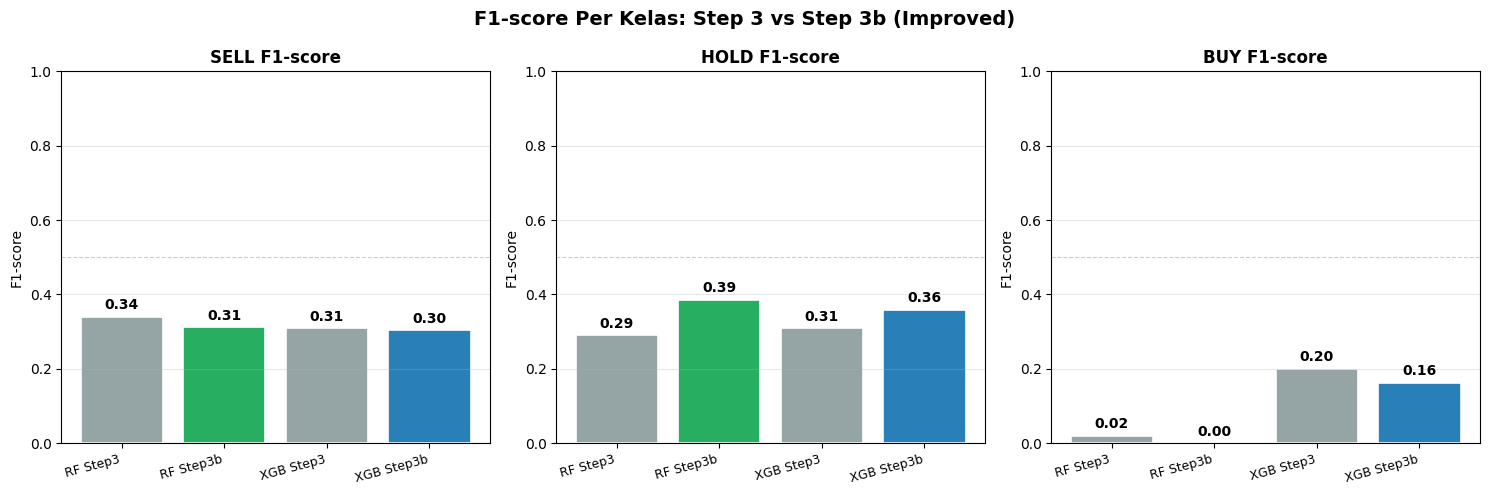

Plot disimpan.


In [9]:
# Visualisasi perbandingan F1 per kelas
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('F1-score Per Kelas: Step 3 vs Step 3b (Improved)', fontsize=14, fontweight='bold')

models    = ['RF Step3', 'RF Step3b', 'XGB Step3', 'XGB Step3b']
colors    = ['#95a5a6', '#27ae60', '#95a5a6', '#2980b9']
classes   = ['sell_f1', 'hold_f1', 'buy_f1']
class_names = ['SELL', 'HOLD', 'BUY']

data_map = {
    'RF Step3'  : results_before['RF (Step 3)'],
    'RF Step3b' : results_after['RF (Step 3b)'],
    'XGB Step3' : results_before['XGB (Step 3)'],
    'XGB Step3b': results_after['XGB (Step 3b)'],
}

for ax, cls, cname in zip(axes, classes, class_names):
    vals = [data_map[m][cls] for m in models]
    bars = ax.bar(models, vals, color=colors, edgecolor='white', linewidth=1.2)
    ax.set_title(f'{cname} F1-score', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.0)
    ax.set_ylabel('F1-score')
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.4, linewidth=0.8)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels(models, rotation=15, ha='right', fontsize=9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
os.makedirs('../../reports', exist_ok=True)
plt.savefig('../../reports/phase2_step3b_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Plot disimpan.')

## Bagian 7 — Feature Importance: Fitur Baru vs Lama

Ini penting untuk dicek: apakah fitur lag dan momentum yang baru
benar-benar dipakai model, atau malah diabaikan?

Model terbaik: XGBoost (F1 macro: 0.275)


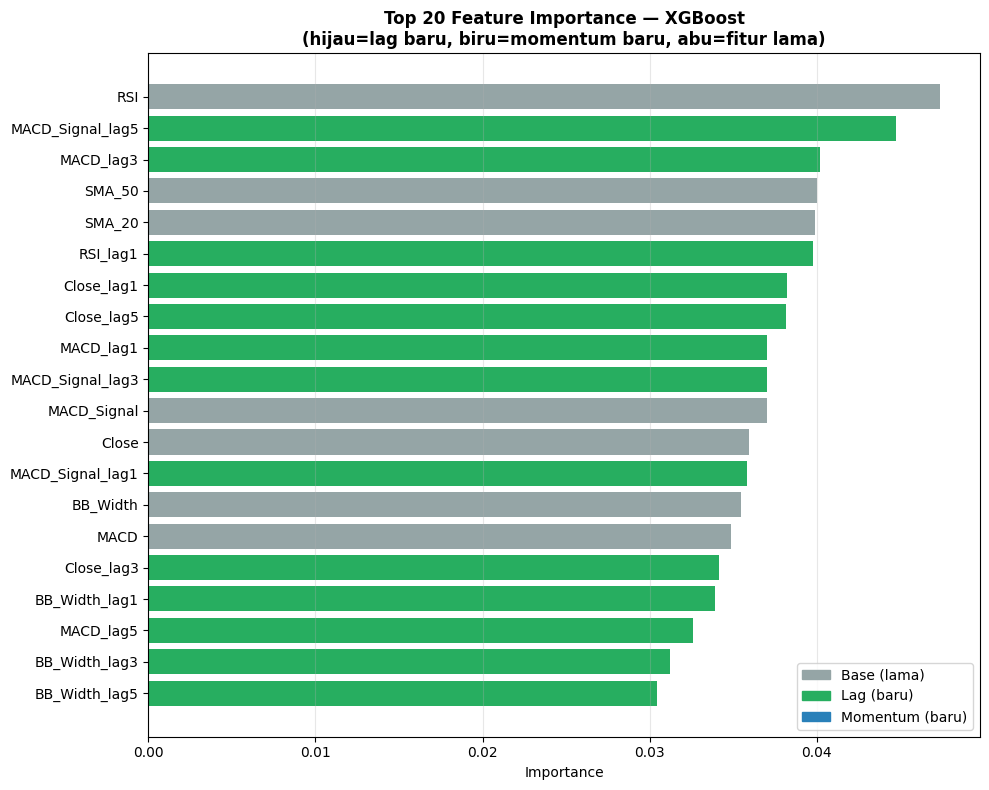


Total importance per kategori fitur:
  Lag (baru)            : 53.2%
  Base (lama)           : 34.8%
  Momentum (baru)       : 12.1%


In [10]:
# Pilih model terbaik
if f1_xgb >= f1_rf:
    best_model = xgb_best
    best_name  = 'XGBoost'
    best_pred  = y_pred_xgb
    best_f1    = f1_xgb
else:
    best_model = rf_best
    best_name  = 'Random Forest'
    best_pred  = y_pred_rf
    best_f1    = f1_rf

print(f'Model terbaik: {best_name} (F1 macro: {best_f1:.3f})')

# Feature importance
importances = best_model.feature_importances_
feat_imp    = sorted(zip(ALL_FEATURES, importances), key=lambda x: x[1], reverse=True)

# Kategorisasi fitur
def feat_category(name):
    if '_lag' in name:   return 'Lag (baru)'
    if name in MOMENTUM_COLS: return 'Momentum (baru)'
    return 'Base (lama)'

cat_colors = {'Base (lama)': '#95a5a6', 'Lag (baru)': '#27ae60', 'Momentum (baru)': '#2980b9'}

# Plot top 20 fitur
top_n  = 20
top    = feat_imp[:top_n]
names  = [f[0] for f in top]
vals   = [f[1] for f in top]
colors = [cat_colors[feat_category(n)] for n in names]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(range(top_n), vals[::-1], color=colors[::-1])
ax.set_yticks(range(top_n))
ax.set_yticklabels(names[::-1], fontsize=10)
ax.set_xlabel('Importance')
ax.set_title(f'Top {top_n} Feature Importance — {best_name}\n(hijau=lag baru, biru=momentum baru, abu=fitur lama)',
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Legend
from matplotlib.patches import Patch
legend = [Patch(color=v, label=k) for k, v in cat_colors.items()]
ax.legend(handles=legend, loc='lower right')

plt.tight_layout()
plt.savefig('../../reports/phase2_step3b_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

# Agregat importance per kategori
cat_totals = {}
for name, imp in feat_imp:
    cat = feat_category(name)
    cat_totals[cat] = cat_totals.get(cat, 0) + imp

print('\nTotal importance per kategori fitur:')
for cat, total in sorted(cat_totals.items(), key=lambda x: x[1], reverse=True):
    print(f'  {cat:<22}: {total*100:.1f}%')

## Bagian 8 — Simpan Model Terbaik

In [ ]:
os.makedirs('../../models', exist_ok=True)

joblib.dump(best_model, f'../../models/best_signal_model_v2.pkl')
joblib.dump(rf_best,    '../../models/rf_signal_model_v2.pkl')
joblib.dump(xgb_best,   '../../models/xgb_signal_model_v2.pkl')
joblib.dump(scaler,     '../../models/signal_scaler_v2.pkl')

meta = {
    'version'        : '3b',
    'all_features'   : ALL_FEATURES,
    'base_features'  : BASE_FEATURES,
    'lag_features'   : LAG_COLS,
    'momentum_features': MOMENTUM_COLS,
    'label_map'      : {'0':'SELL','1':'HOLD','2':'BUY'},
    'rf_acc'         : round(acc_rf, 4),
    'rf_f1_macro'    : round(f1_rf, 4),
    'xgb_acc'        : round(acc_xgb, 4),
    'xgb_f1_macro'   : round(f1_xgb, 4),
    'best_model'     : best_name,
    'improvements'   : ['lag_features', 'momentum_features', 'hyperparameter_tuning']
}
with open('../../models/signal_model_meta_v2.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('=== Model v2 Tersimpan ===')
print(f'Best model : {best_name}')
print(f'RF   — Akurasi: {acc_rf*100:.1f}%  F1: {f1_rf:.3f}  (was: 26.6% / 0.222)')
print(f'XGB  — Akurasi: {acc_xgb*100:.1f}%  F1: {f1_xgb:.3f}  (was: 28.4% / 0.273)')
print()
print('✅ Siap lanjut ke Step 4 — Backtesting!')

=== Model v2 Tersimpan ===
Best model : XGBoost
RF   — Akurasi: 28.7%  F1: 0.233  (was: 26.6% / 0.222)
XGB  — Akurasi: 29.3%  F1: 0.275  (was: 28.4% / 0.273)

✅ Siap lanjut ke Step 4 — Backtesting!


---

## Ringkasan perbaikan

| Perbaikan | Detail | Dampak |
|---|---|---|
| Lag features | RSI/MACD/Close/BB_Width/MACD_Signal 1,3,5 hari lalu | Model tahu arah pergerakan indikator |
| Momentum features | Return 3d/5d, RSI slope, MACD crossover, Volume momentum | Tangkap tren jangka pendek |
| Hyperparameter tuning | RandomizedSearchCV 30 iterasi, F1 macro scoring | Parameter optimal per model |

## Kenapa akurasi mungkin masih tidak tinggi?

Saham AAPL 2023–2024 (periode test) adalah periode dengan banyak
ketidakpastian makro — suku bunga tinggi, AI boom, volatilitas tinggi.
Pola teknikal yang dipelajari dari 2018–2022 belum tentu berlaku sama.

Ini bukan kegagalan model — ini realita pasar saham.
Yang lebih penting dari akurasi adalah **apakah sinyal yang benar
muncul di momen yang menguntungkan** — itulah yang akan kita ukur
di Step 4 melalui backtesting.